In [56]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [57]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all_no_dup.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
anno.collect_schema().names()

diff_vars = (
    anno
    .filter(
        pl.col('ac_ukb')>=20, 
        pl.col('mac_ukb')<=20,
    )
    .collect(engine='streaming')
)

diff_vars

Error: path "/home/dnanexus/data_dir/annotations_with_all_no_dup.parquet"
already exists but -f/--overwrite was not set


id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,esmscoreframeshift,…,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,protein_position,amino_acids,revel_score,cpt1_llr,cpt1_llr_is_na,esm1b_llr_is_na,revel_score_is_na,clinpred_score,clinpred_score_is_na,bayes_del_is_na,gene_name,popeve_score_is_na,eve_score_is_na,pop_adj_eve_is_na,pop_adj_esm1v_is_na,not_annotated_in_encode,encode_dels,encode_ca-ctcf,encode_ca,encode_ca-h3k4me3,encode_tf,encode_ca-tf,encode_pels,encode_pls,clinical_significance,bayes_del,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,tss_pos_v39,dist2tssv39
str,str,i64,str,str,str,f32,f32,f32,f32,f32,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,f32,…,i64,bool,bool,bool,str,str,f32,f32,i32,i32,i32,f32,i32,i32,str,i32,i32,i32,i32,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,f32,bool,bool,bool,bool,bool,i64,i64
"""chr1:62215349:T:G""","""chr1""",62215349,"""T""","""G""","""ENSG00000240563""",1.0,0.0,4.997,0.45557,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-3.79,0.0,0.0,0.0,17481,20501,0.0,0.0,0.04,0.0,0.0,…,20,false,false,false,null,null,0.0,0.0,1,1,1,0.0,1,1,"""L1TD1""",0,0,0,0,false,false,false,true,false,false,false,false,false,null,-0.249576,false,false,false,false,false,62194848,20501
"""chr6:75978188:T:C""","""chr6""",75978188,"""T""","""C""","""ENSG00000112706""",1.0,0.0,2.062,0.171971,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.19,0.0,0.0,0.005501,151566,94490,0.0,0.0,0.013,0.0,0.0,…,20,false,false,false,null,null,0.0,0.0,1,1,1,0.0,1,1,"""IMPG1""",0,0,0,0,true,false,false,false,false,false,false,false,false,null,-0.249576,false,false,false,false,false,75921113,57075
"""chr16:87633472:T:A""","""chr16""",87633472,"""T""","""A""","""ENSG00000154118""",1.0,0.0,4.486,0.408621,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.54,0.0,0.0,0.006358,96323,31638,0.0,0.0,0.067,0.0,0.0,…,20,false,false,false,null,null,0.0,0.0,1,1,1,0.0,1,1,"""JPH3""",0,0,0,0,true,false,false,false,false,false,false,false,false,null,-0.249576,false,false,false,false,false,87602507,30965
"""chr11:14806858:C:A""","""chr11""",14806858,"""C""","""A""","""ENSG00000152270""",1.0,0.0,2.042,0.169387,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,0.11,0.0,0.0,0.006871,228242,163055,0.0,0.0,0.067,0.0,0.0,…,20,false,false,false,null,null,0.0,0.0,1,1,1,0.0,1,1,"""PDE3B""",0,0,0,0,true,false,false,false,false,false,false,false,false,null,-0.249576,false,false,false,false,false,14643803,163055
"""chr10:99143672:A:T""","""chr10""",99143672,"""A""","""T""","""ENSG00000172987""",1.0,0.0,8.898,0.863478,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.005,0.000395,0,0,0,0,0,1,-0.51,0.0,0.0,0.042189,778787,92190,0.0,0.0,0.0,0.0,0.0,…,20,false,false,false,null,null,0.0,0.0,1,1,1,0.0,1,1,"""HPSE2""",0,0,0,0,true,false,false,false,false,false,false,false,false,null,-0.249576,false,false,false,false,false,98457076,686596
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr7:76299863:TTC:T""","""chr7""",76299863,"""TTC""","""T""","""ENSG00000106211""",1.0,0.0,0.628,-0.136136,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,3,-1.41,0.0,0.0,0.0,1624,-2809,0.0,0.0,0.0,0.0,0.0,…,20,false,false,false,null,null,0.0,0.0,1,1,1,0.0,1,1,"""HSPB1""",0,0,0,0,true,false,false,false,false,false,false,false,false,null,-0.249576,fal

In [58]:
diff_vars['loftee_hc'].value_counts()

loftee_hc,count
i8,u64
1,267
0,326214


In [59]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')

gene_trait_df = (
    gene_trait_df
    .with_columns(
        pval_bh = pl.Series(
            multipletests(gene_trait_df['pval'].to_numpy(), method='fdr_bh')[1]
        ),
        pval_by = pl.Series(
            multipletests(gene_trait_df['pval'].to_numpy(), method='fdr_by')[1]
        )
    )
    # .filter(pl.col('pval_bh')<=0.05)
    .filter(pl.col('pval_by')<=0.05)
    .unique(subset=["region"], keep="first", maintain_order=True)
    # .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
# !dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

# loftee_corrs = (
#     pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
#     .with_columns(
#         loftee_corr = pl.col('correlation'),
#         loftee_corr_abs = pl.col('correlation').abs(),
#         loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
#     )
#     .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
# )

# gene_trait_df = (
#     gene_trait_df
#     .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
#     .drop_nans()
#     .sort('loftee_corr_abs', descending=True)
#     .unique(subset=["region"], keep="first", maintain_order=True)
# )

gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set


region,chr,phenotype,cohort,model,effect,lci_effect,uci_effect,pval,aaf,num_cases,cases_ref,cases_het,cases_alt,num_controls,controls_ref,controls_het,controls_alt,info,pval_fdr,pval_bonf,pval_bh,pval_by
str,i64,str,str,str,f64,f64,f64,f64,f64,i64,i64,i64,i64,str,str,str,str,str,f64,f64,f64,f64
"""ENSG00000132855""",1,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.46207,-0.612266,-0.311875,1.6422e-9,0.000166,386584,386456,128,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.076632;MAC=128.00…",0.000007,0.003328,0.000006,0.000092
"""ENSG00000110243""",11,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.449444,-0.633744,-0.265144,0.000002,0.00011,386584,386499,85,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.094032;MAC=85.001…",0.003376,1.0,0.002909,0.043386
"""ENSG00000118137""",11,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-2.60164,-2.94144,-2.26184,6.6771e-51,0.000032,386584,386559,25,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.173370;MAC=25.000…",4.5099e-46,1.3530e-44,3.7467e-46,5.5877e-45
"""ENSG00000166035""",15,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",0.616484,0.436378,0.796589,1.9629e-11,0.000115,386584,386495,89,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.091892;MAC=89.001…",1.2507e-7,0.00004,1.0625e-7,0.000002
"""ENSG00000140479""",15,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.647847,-0.893119,-0.402575,2.2557e-7,0.000123,386584,386395,189,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.125141;MAC=95.001…",0.000568,0.457077,0.000489,0.007298
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000064999""",6,"""platelet_distribution_width_in…","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",0.571022,0.351223,0.790821,3.5458e-7,0.000079,432177,432109,68,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.112144;MAC=68.001…",0.000836,0.718497,0.000724,0.01079
"""ENSG00000147459""",8,"""platelet_distribution_width_in…","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.296031,-0.403046,-0.189015,5.9021e-8,0.000332,432177,431890,287,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.054601;MAC=287.00…",0.000178,0.119596,0.000153,0.002283
"""ENSG00000198198""",1,"""creatinine_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.352394,-0.484497,-0.220291,1.7104e-7,0.000304,424515,424001,514,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.067401;MAC=258.00…",0.000448,0.346576,0.000385,0.005748


In [60]:
RVAT_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/association_files"
LOCAL_DIR = "/home/dnanexus/data_dir/"

ac = 20

!dx download {RVAT_DIR}/loftee_hc_sum_ac{ac}_association_testing_results.parquet -o {LOCAL_DIR}
!dx download {RVAT_DIR}/am_pathogenicity_sum_ac{ac}_association_testing_results.parquet -o {LOCAL_DIR}

Error: path "/home/dnanexus/data_dir/loftee_hc_sum_ac20_association_testing_re
sults.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/am_pathogenicity_sum_ac20_association_tes
ting_results.parquet" already exists but -f/--overwrite was not set


In [75]:
lof = pl.read_parquet(f'{LOCAL_DIR}/loftee_hc_sum_ac{ac}_association_testing_results.parquet')
lof = (
    lof
    .with_columns(
        pval_bh = pl.Series(
            multipletests(lof['pval'].to_numpy(), method='fdr_bh')[1]
        ),
        pval_by = pl.Series(
            multipletests(lof['pval'].to_numpy(), method='fdr_by')[1]
        )
    )
    .filter((pl.col('pval_bh')<=0.05) | (pl.col('pval_by')<=0.05))
    # .filter(pl.col('pval_by')<=0.05)
    # .unique(subset=["gene"], keep="first", maintain_order=True)
)

lof

gene,pval,beta,trait,pval_bh,pval_by
str,f64,f64,str,f64,f64
"""ENSG00000157766""",0.000006,-0.367628,"""hand_grip_strength_left_p46_i0""",0.008225,0.122766
"""ENSG00000173875""",0.000003,-1.546733,"""hand_grip_strength_left_p46_i0""",0.004444,0.066336
"""ENSG00000162733""",0.000004,-0.465052,"""hand_grip_strength_left_p46_i0""",0.005731,0.085544
"""ENSG00000198720""",0.00006,-0.374777,"""hand_grip_strength_left_p46_i0""",0.047191,0.704396
"""ENSG00000166963""",0.000021,-0.241158,"""hand_grip_strength_left_p46_i0""",0.021619,0.322694
…,…,…,…,…,…
"""ENSG00000164867""",0.000056,0.218957,"""diastolic_blood_pressure_autom…",0.044791,0.668576
"""ENSG00000134250""",0.000019,-0.444555,"""diastolic_blood_pressure_autom…",0.020638,0.308052
"""ENSG00000137834""",1.8900e-8,0.264255,"""systolic_blood_pressure_automa…",0.000062,0.00092


/tmp/ipykernel_29516/976853788.py:27: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)


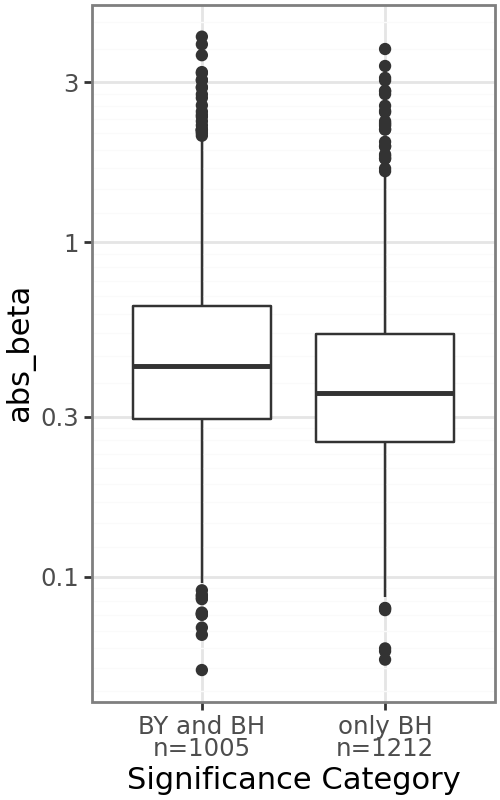

In [76]:
lof_plot = (
    lof
    .with_columns(
        abs_beta = pl.col('beta').abs(),
        neg_log10_pval_bh = -pl.col('pval_bh').log10(),
        neg_log10_pval_by = -pl.col('pval_by').log10(),
        signif = (
            pl.when((pl.col('pval_by')<=0.05) & (pl.col('pval_bh')<=0.05))
            .then(pl.lit('BY and BH'))
            .otherwise(
                pl.when(pl.col('pval_by')<=0.05)
                .then(pl.lit('only BY'))
                .otherwise(
                    pl.when(pl.col('pval_bh')<=0.05)
                    .then(pl.lit('only BH'))
                    .otherwise(pl.lit('Not significant'))
                )
            )
        )
    )
)

# Calculate sample sizes for each group
n_stats = (
    lof_plot
    .group_by('signif')
    .agg(pl.count().alias('n'))
    .with_columns(
        signif_label = pl.concat_str([pl.col('signif'), pl.lit('\nn='), pl.col('n')])
    )
)

lof_plot_with_n = lof_plot.join(n_stats[['signif', 'signif_label']], on='signif')

(
    ggplot(lof_plot_with_n, aes(x='signif_label', y='abs_beta'))
    + geom_boxplot()
    + scale_y_log10()
    + theme_bw()
    + theme(
        figure_size=(2.5, 4),
    )
    + labs(x='Significance Category')
)

In [79]:
am = pl.read_parquet(f'{LOCAL_DIR}/am_pathogenicity_sum_ac{ac}_association_testing_results.parquet')

am = (
    am
    .with_columns(
        pval_bh = pl.Series(
            multipletests(am['pval'].to_numpy(), method='fdr_bh')[1]
        ),
        pval_by = pl.Series(
            multipletests(am['pval'].to_numpy(), method='fdr_by')[1]
        )
    )
    .filter((pl.col('pval_bh')<=0.05) | (pl.col('pval_by')<=0.05))
    # .filter(pl.col('pval_by')<=0.05)
    # .unique(subset=["gene"], keep="first", maintain_order=True)
)

am

gene,pval,beta,trait,pval_bh,pval_by
str,f64,f64,str,f64,f64
"""ENSG00000171862""",0.000003,-0.344668,"""hand_grip_strength_left_p46_i0""",0.007707,0.115039
"""ENSG00000179295""",8.2511e-9,-0.257859,"""hand_grip_strength_left_p46_i0""",0.000042,0.000621
"""ENSG00000136928""",8.2607e-8,-0.253256,"""hand_grip_strength_left_p46_i0""",0.000332,0.00496
"""ENSG00000142675""",0.000024,-2.572971,"""hand_grip_strength_left_p46_i0""",0.041681,0.622156
"""ENSG00000196296""",7.9248e-7,0.120532,"""hand_grip_strength_left_p46_i0""",0.00244,0.036415
…,…,…,…,…,…
"""ENSG00000164362""",0.000009,-0.447427,"""diastolic_blood_pressure_autom…",0.018806,0.280705
"""ENSG00000179295""",5.2867e-7,-0.297189,"""diastolic_blood_pressure_autom…",0.001688,0.025202
"""ENSG00000182511""",5.1415e-10,0.271175,"""systolic_blood_pressure_automa…",0.000003,0.000049


/tmp/ipykernel_29516/653475838.py:27: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)


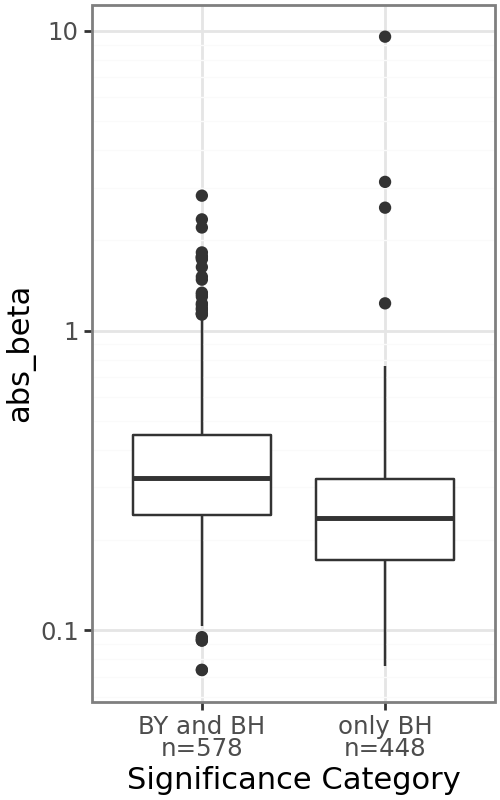

In [80]:
am_plot = (
    am
    .with_columns(
        abs_beta = pl.col('beta').abs(),
        neg_log10_pval_bh = -pl.col('pval_bh').log10(),
        neg_log10_pval_by = -pl.col('pval_by').log10(),
        signif = (
            pl.when((pl.col('pval_by')<=0.05) & (pl.col('pval_bh')<=0.05))
            .then(pl.lit('BY and BH'))
            .otherwise(
                pl.when(pl.col('pval_by')<=0.05)
                .then(pl.lit('only BY'))
                .otherwise(
                    pl.when(pl.col('pval_bh')<=0.05)
                    .then(pl.lit('only BH'))
                    .otherwise(pl.lit('Not significant'))
                )
            )
        )
    )
)

# Calculate sample sizes for each group
n_stats = (
    am_plot
    .group_by('signif')
    .agg(pl.count().alias('n'))
    .with_columns(
        signif_label = pl.concat_str([pl.col('signif'), pl.lit('\nn='), pl.col('n')])
    )
)

am_plot_with_n = am_plot.join(n_stats[['signif', 'signif_label']], on='signif')

(
    ggplot(am_plot_with_n, aes(x='signif_label', y='abs_beta'))
    + geom_boxplot()
    + scale_y_log10()
    + theme_bw()
    + theme(
        figure_size=(2.5, 4),
    )
    + labs(x='Significance Category')
)